# Agentic AI Fundamentals

## Notebook 01: LLM Call, Chain, Workflow, Router, or Agent?

Modern AI applications are frequently described as agents even when their execution path is completely predetermined. This loose terminology makes systems sound more advanced, but it also makes their behavior harder to reason about. Before building an agent, we should be able to recognize when a single model call, a short chain, or a deterministic workflow would solve the problem more reliably.

In this notebook, we will implement five common application patterns with plain Python. The examples are intentionally small because our objective is to understand who controls the next step in each architecture.

## Learning objectives

By the end of this notebook, you should be able to:

- distinguish an LLM call, chain, workflow, router, and agent;
- identify whether the developer or the model controls the execution path;
- choose the least complex architecture that satisfies a task; and
- explain why an agent is useful only when runtime decisions genuinely require flexibility.

The examples remain local and deterministic. Real model calls will be introduced after we establish structured outputs and tool contracts, because those concepts allow us to connect an API without treating its output as automatically trustworthy.

### The core idea: who decides what happens next?

The main difference between these architectures is not how many LLM calls they make. The key question is **who controls the next step: the developer or the model?**

A simple way to think about the progression:

```text
Single LLM Call
      │
      │  One request → one response
      ▼
     Done


Chain
      │
      │  Step A → Step B → Step C
      ▼
     Done


Workflow
      │
      ├── condition A → Path A
      │
      └── condition B → Path B
              ↑
      Developer defines the rules


Router
      │
      │  Choose one destination
      ├── Billing
      ├── Technical
      └── General


Agent
      │
      │  Observe current state
      ▼
   Choose action
      │
      ▼
   Use a tool
      │
      ▼
   Observe result
      │
      └──────────→ Choose again
                       │
                       ▼
                  Final answer


```

The amount of flexibility increases as we move down the list. An agent is different because it can use new observations to decide what should happen next instead of following a fully predetermined path.

## 1. Single LLM call

A single-call application sends one request to a model and returns its response. This pattern is appropriate when the task can be completed from the supplied context without external actions or multiple reasoning stages.

Typical examples include rewriting a paragraph, classifying a short message, extracting fields into a schema, or summarizing a document that already fits into the model context.

We will represent the model with a deterministic function so the architectural pattern remains visible.

In [ ]:
def text_model(instruction: str, text: str) -> str:
    """A deterministic substitute for a text-generation model."""

    if instruction == "summarize":
        words = text.split()
        shortened = " ".join(words[:12])
        return shortened + ("..." if len(words) > 12 else "")

    if instruction == "uppercase":
        return text.upper()

    raise ValueError(f"Unsupported instruction: {instruction}")


paragraph = (
    "Agentic systems combine language-model decisions with application-managed "
    "tools, state, execution policies, and termination conditions."
)

summary = text_model("summarize", paragraph)
print(summary)

Agentic systems combine language-model decisions with application-managed tools, state, execution policies, and...


The application performs exactly one model-like operation. There is no loop, no external tool, and no runtime choice between alternative steps. Calling this an agent would add terminology without adding explanatory value.

## 2. Chain

A chain connects several operations in a fixed sequence. Each stage receives the output of the previous stage, but the developer has already decided the order.

A chain can contain multiple model calls, ordinary functions, or both. The number of model calls does not determine whether the system is an agent; control over the execution path is the more useful distinction.

In [ ]:
def clean_text(text: str) -> str:
    return " ".join(text.split())


def summarize_text(text: str) -> str:
    return text_model("summarize", text)


def format_result(text: str) -> str:
    return f"SUMMARY: {text}"


raw_text = (
    "An agent should have an explicit action space.     The application "
    "must validate requested actions before execution, and every run "
    "should have a clear termination condition."
)

cleaned_text = clean_text(raw_text)
summarized_text = summarize_text(cleaned_text)
formatted_summary = format_result(summarized_text)

print(formatted_summary)

SUMMARY: An agent should have an explicit action space. The application must validate...


The path is always:

```text
        clean → summarize → format
```

The content changes between runs, but the control flow does not. This predictability makes chains easy to inspect and test.

## 3. Deterministic workflow

A workflow adds branching, validation, retries, or parallel stages, but those transitions are still encoded by the developer. The workflow can react to data without delegating the decision to a language model.

In the following example, document length determines which summarization strategy runs. The condition is explicit and reproducible.

In [ ]:
def short_document_summary(text: str) -> str:
    return text_model("summarize", text)


def long_document_summary(text: str) -> str:
    words = text.split()
    midpoint = len(words) // 2

    first_half = text_model("summarize", " ".join(words[:midpoint]))
    second_half = text_model("summarize", " ".join(words[midpoint:]))

    return f"{first_half} | {second_half}"


def summarization_workflow(text: str, long_threshold: int = 30) -> dict:
    word_count = len(text.split())

    if word_count <= long_threshold:
        strategy = "single_pass"
        result = short_document_summary(text)
    else:
        strategy = "split_then_summarize"
        result = long_document_summary(text)

    return {
        "word_count": word_count,
        "strategy": strategy,
        "summary": result,
    }


short_document = "A tool is a controlled capability exposed by an application."

workflow_result = summarization_workflow(short_document)
print(workflow_result)

{'word_count': 10, 'strategy': 'single_pass', 'summary': 'A tool is a controlled capability exposed by an application.'}


This system branches, but it is not agentic. The developer selected the routing rule, the available branches, and the stopping point. That is often desirable: if a reliable rule already exists, replacing it with a model decision would introduce cost and variability without creating meaningful value.

## 4. Router

A router selects one destination from a known set. The routing decision can be implemented with ordinary rules, a classifier, or an LLM. An LLM-based router is more dynamic than a fixed conditional, but it still does not necessarily form a complete agent.

The key question is what happens after routing. If the system selects one predefined handler and then stops, it is best understood as a routed workflow. If it can repeatedly inspect results and choose further actions, it begins to resemble an agent loop.

In [ ]:
def route_request(user_message: str) -> str:
    normalized_message = user_message.casefold()

    if any(word in normalized_message for word in {"multiply", "calculate", "sum"}):
        return "calculator"

    if any(word in normalized_message for word in {"document", "policy", "notes"}):
        return "knowledge_search"

    return "general_response"


requests = [
    "Calculate 24 multiplied by 17.",
    "Search the policy document for the retention period.",
    "Explain why tools need input schemas.",
]

for request in requests:
    destination = route_request(request)
    print(f"{request}\n  → {destination}\n")

Calculate 24 multiplied by 17.
  → calculator

Search the policy document for the retention period.
  → knowledge_search

Explain why tools need input schemas.
  → general_response



The router chooses among destinations, but it does not observe the result and make another decision. Routing is an important part of many agents, yet routing alone is not sufficient to make a system an agent.

## 5. Agent

An agent places a model-driven decision inside a controlled loop. At each iteration, the system considers its current state and chooses whether to use a tool, request clarification, or return a final answer. Tool observations modify the state and may change the next decision.

The simplified example below does not call a real model yet. It uses explicit decisions so we can focus on the loop itself.

In [ ]:
from typing import Any


def multiply(first_number: float, second_number: float) -> float:
    return first_number * second_number


tools = {
    "multiply": multiply,
}


scripted_decisions = iter(
    [
        {
            "type": "tool_request",
            "tool_name": "multiply",
            "arguments": {
                "first_number": 24,
                "second_number": 17,
            },
        },
        {
            "type": "final_answer",
            "answer": "24 multiplied by 17 is 408.",
        },
    ]
)


def decide_next_action(state: list[dict[str, Any]]) -> dict[str, Any]:
    """Simulate successive model decisions for this example."""

    return next(scripted_decisions)

In [ ]:
def run_agent(user_message: str, max_steps: int = 4) -> dict[str, Any]:
    state: list[dict[str, Any]] = [
        {"type": "user_message", "content": user_message}
    ]

    for step_number in range(1, max_steps + 1):
        decision = decide_next_action(state)
        state.append({"type": "model_decision", "content": decision})

        if decision["type"] == "final_answer":
            return {
                "status": "completed",
                "answer": decision["answer"],
                "steps": step_number,
                "state": state,
            }

        if decision["type"] != "tool_request":
            raise ValueError(f"Unsupported decision type: {decision['type']}")

        tool_name = decision["tool_name"]

        if tool_name not in tools:
            observation = {
                "success": False,
                "error": f"Unknown tool: {tool_name}",
            }
        else:
            try:
                result = tools[tool_name](**decision["arguments"])
                observation = {"success": True, "result": result}
            except Exception as error:
                observation = {
                    "success": False,
                    "error": f"{type(error).__name__}: {error}",
                }

        state.append(
            {
                "type": "tool_observation",
                "tool_name": tool_name,
                "content": observation,
            }
        )

    return {
        "status": "stopped",
        "reason": f"Maximum step count reached: {max_steps}",
        "state": state,
    }


agent_result = run_agent("Calculate 24 multiplied by 17.")
print(agent_result["answer"])
print("Steps used:", agent_result["steps"])

24 multiplied by 17 is 408.
Steps used: 2


The important difference is not that the system used a tool. A deterministic workflow can also use tools. The difference is that the next action is selected from the current state, and the cycle can continue after an observation.

The `max_steps` parameter is equally important. Without a termination limit, a model could repeatedly request tools and create an unbounded run.

## 6. Compare the five patterns

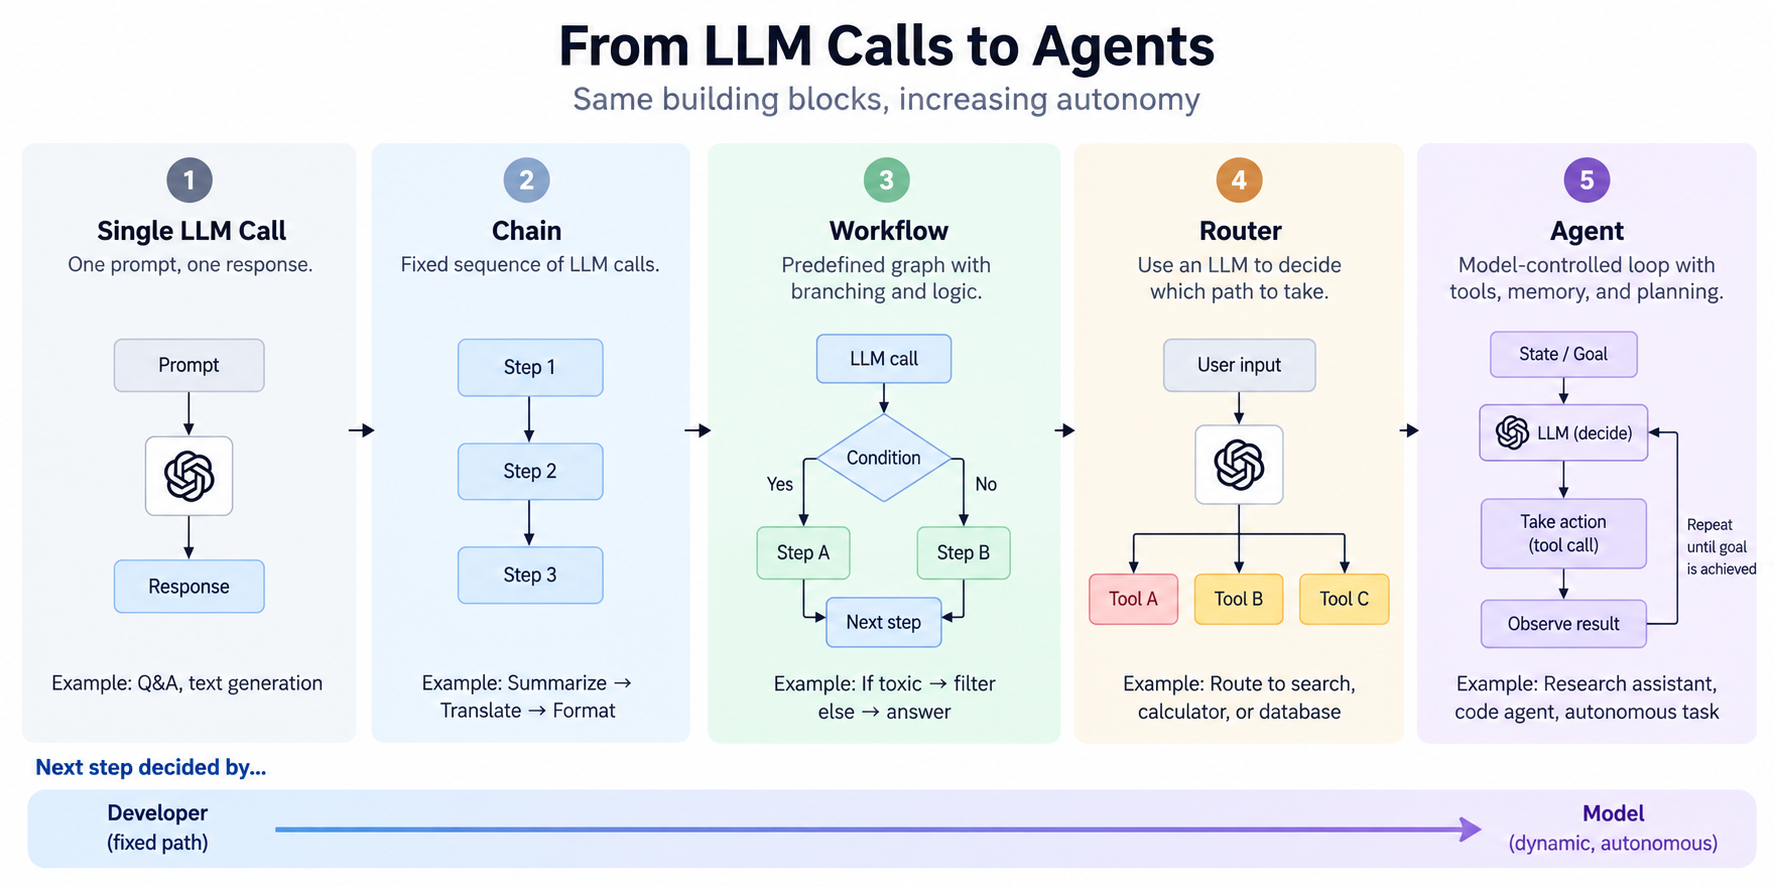



| Pattern | Who determines the path? | Can it branch? | Can it repeat actions? | Typical use |
|---|---|---:|---:|---|
| Single LLM call | Developer | No | No | Rewrite, extraction, classification |
| Chain | Developer | Usually no | No | Fixed multi-stage transformation |
| Workflow | Developer-defined rules | Yes | If explicitly programmed | Reliable business process |
| Router | Rule, classifier, or model | Selects a destination | Usually no | Intent routing and specialization |
| Agent | Model within application constraints | Yes | Yes, until a stop condition | Open-ended tool use |

These categories are architectural patterns rather than strict product labels. A production system may combine them. For example, a deterministic workflow might contain one agentic step, or an agent might invoke a reliable workflow as a tool.

## 7. A practical selection rule

Start with the least autonomous design that can solve the task:

1. Use a normal function when ordinary code is sufficient.
2. Use one model call when the task requires language understanding but no external action.
3. Use a chain when the sequence is fixed.
4. Use a workflow when explicit conditions can handle branching.
5. Use a router when one request must be assigned to one specialized path.
6. Use an agent when runtime observations must influence a sequence of actions that cannot be fully specified in advance.

This ordering is not anti-agent. It keeps the agent focused on decisions where flexibility is valuable instead of using model autonomy to replace dependable application logic.

## 8. Exercise: classify the architecture

Assign each scenario to the simplest suitable pattern: **single LLM call**, **chain**, **workflow**, **router**, or **agent**.

1. Convert a customer email into a fixed JSON schema.
2. Translate a paragraph, proofread the translation, and format it for publication.
3. Reject files larger than 10 MB; otherwise extract and index their text.
4. Send billing questions to one handler and technical questions to another.
5. Investigate a service outage by deciding whether to inspect logs, metrics, deployment history, or configuration, and continue until enough evidence is collected.

Write your answers before opening the solution.

<details>
<summary><strong>Suggested solution</strong></summary>

1. **Single LLM call:** the request has one transformation and a fixed output schema.
2. **Chain:** the three operations always run in the same order.
3. **Workflow:** an explicit size rule determines whether processing continues.
4. **Router:** one classification selects one specialized destination.
5. **Agent:** new evidence influences which diagnostic action should happen next.

Alternative answers may be valid if the scenario is interpreted differently, but the justification should identify who controls the path and whether observations influence later decisions.

</details>

## 9. Coding exercise: convert a router into a workflow

Complete `support_workflow`. It should route the message, call the corresponding handler, and return both the selected route and the generated response.

In [ ]:
def billing_handler(message: str) -> str:
    return f"Billing queue received: {message}"


def technical_handler(message: str) -> str:
    return f"Technical queue received: {message}"


def support_router(message: str) -> str:
    normalized_message = message.casefold()

    if any(word in normalized_message for word in {"invoice", "payment", "refund"}):
        return "billing"

    return "technical"


def support_workflow(message: str) -> dict[str, str]:
    # 1. Select a route with support_router.
    # 2. Call the correct handler.
    # 3. Return {"route": ..., "response": ...}.
    raise NotImplementedError

<details>
<summary><strong>Reveal one possible solution</strong></summary>

```python
def support_workflow(message: str) -> dict[str, str]:
    route = support_router(message)

    if route == "billing":
        response = billing_handler(message)
    else:
        response = technical_handler(message)

    return {
        "route": route,
        "response": response,
    }


print(support_workflow("I need a refund for my last payment."))
```

Although the workflow routes dynamically, every possible transition remains explicitly programmed. It is therefore not an agent.

</details>

## Notebook summary

We implemented five related but distinct patterns. A single model call performs one language task. A chain connects fixed stages. A workflow uses developer-defined branching. A router selects one destination. An agent repeatedly chooses actions based on evolving state and observations.

The next notebook introduces structured outputs with Pydantic. That step matters because a real model API can produce malformed or unsupported action requests, and application code needs a reliable contract before connecting model decisions to executable tools.